# Notebook 2 — Why This Matters for Ambient-Noise Cross-Correlation

Notebook 1 established multitaper spectral estimation in the abstract: fewer,
better-chosen tapers give a lower-leakage, faster-to-compute spectral
estimate than the periodogram or a naive full taper set. This notebook makes
the connection concrete for the actual problem Sayan's project addresses:
extracting **Love-wave dispersion curves from ambient-noise cross-correlations**
across the Madagascar network (Olugboji & Xue 2022, "ADAMA"), where
Rayleigh waves work well with existing methods and Love waves specifically
do not.

Sources: Sayan's course project report and presentation slides 3-6
(`antigravity-context/SSWAR_ESC425_Project_Report.pdf`,
`SSWAR_ESC425_Presentstion.pptx`), and the same Karnik et al. (2022) paper
as Notebook 1.


In [1]:
import sys
sys.path.insert(0, '../python')
import numpy as np
from scipy.special import j0
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100


## 1. From cross-correlation to phase velocity: the Bessel-function link

For two stations recording a diffuse, stationary ambient noise wavefield,
the cross-correlation of their recordings is (up to normalization) an
estimate of the Green's function between them — this is the physical basis
of ambient-noise seismology. Aki (1957) showed that for an isotropic,
diffuse wavefield, the **real part of the spectral coherence** between two
receivers separated by distance $r$ is well approximated by the zeroth-order
Bessel function of the first kind:

$$
\mathrm{Re}\{\gamma_{ab}(f)\} \approx J_0\!\left(\frac{2\pi f r}{c(f)}\right),
\qquad
\gamma_{ab}(f) = \frac{\langle u_a(f) u_b^*(f)\rangle}{\sqrt{\langle |u_a(f)|^2\rangle \langle |u_b(f)|^2\rangle}}
$$

where $c(f)$ is the frequency-dependent phase velocity (Yokoi & Margaryan
2008 establish the consistency of this "SPAC" relation with seismic
interferometry more generally). **Fitting the observed coherence spectrum to
this Bessel function** — by grid search or waveform fitting over trial
velocities $c(f)$ — is exactly how a phase-velocity dispersion curve $c(f)$
gets extracted from a station pair's cross-correlation.

The key sensitivity: **the quality of the Bessel-function fit is only as
good as the coherence estimate feeding it.** A noisy, high-variance $\gamma_{ab}(f)$
has no clean, unambiguous zero-crossings to fit against — which is precisely
where spectral estimation quality (Notebook 1's whole subject) enters the
picture.

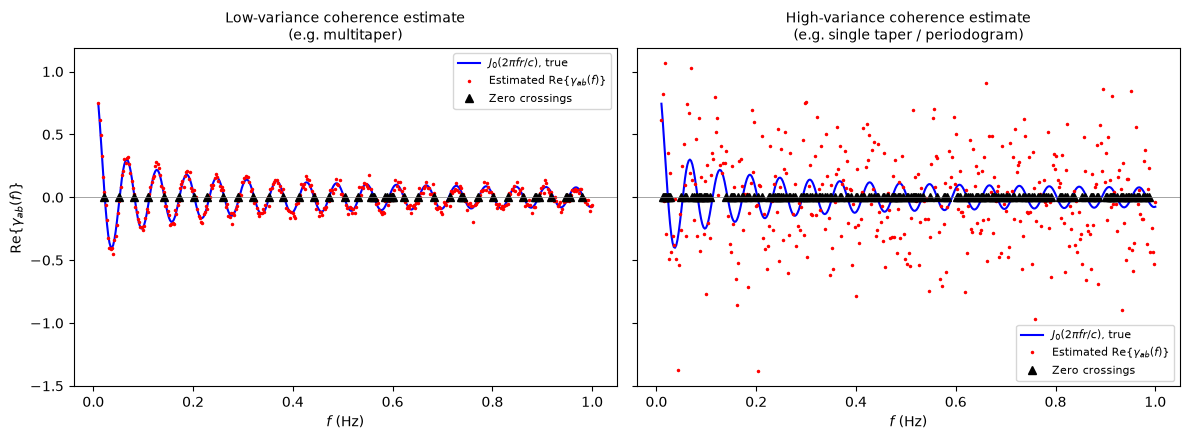

Clean estimate: 45 zero crossings detected
Noisy estimate: 187 zero crossings detected (spurious crossings from noise, not signal)


In [2]:
# Illustration: a clean vs. noisy coherence estimate and what that does to Bessel-fitting.
rng = np.random.default_rng(0)
f = np.linspace(0.01, 1.0, 400)
r = 50.0        # km
c_true = 3.0    # km/s, flat dispersion for illustration
true_coh = j0(2 * np.pi * f * r / c_true)

clean = true_coh + rng.normal(0, 0.03, size=f.size)
noisy = true_coh + rng.normal(0, 0.35, size=f.size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (title, y) in zip(axes, [('Low-variance coherence estimate\n(e.g. multitaper)', clean),
                                    ('High-variance coherence estimate\n(e.g. single taper / periodogram)', noisy)]):
    ax.plot(f, true_coh, 'b-', linewidth=1.5, label='$J_0(2\\pi f r / c)$, true')
    ax.plot(f, y, 'r.', markersize=3, label='Estimated $\\mathrm{Re}\\{\\gamma_{ab}(f)\\}$')
    zero_crossings = f[:-1][np.diff(np.sign(y)) != 0]
    ax.plot(zero_crossings, np.zeros_like(zero_crossings), 'k^', markersize=6, label='Zero crossings')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('$f$ (Hz)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
axes[0].set_ylabel(r'$\mathrm{Re}\{\gamma_{ab}(f)\}$')
plt.tight_layout()
plt.show()

print(f"Clean estimate: {len(f[:-1][np.diff(np.sign(clean)) != 0])} zero crossings detected")
print(f"Noisy estimate: {len(f[:-1][np.diff(np.sign(noisy)) != 0])} zero crossings detected "
      "(spurious crossings from noise, not signal)")


With the low-variance estimate, the zero crossings line up cleanly
with the true Bessel function's — exactly what a dispersion-picking
algorithm like `seislib`'s `extract_dispcurve` (Notebook 3, Section 4) needs
to converge on a stable curve. With the high-variance estimate, spurious
zero crossings appear purely from noise, which is exactly the failure mode
Sayan's report documents for Love waves with conventional single-taper
processing (see Section 2 below, and the report's own Fig. 6-7 zero-crossing
comparison, reproduced with the real `seislib` package in Notebook 3).


## 2. Why this is specifically a Love-wave problem

Sayan's report and presentation are explicit that this is not a generic
"spectral estimation would be nice everywhere" argument — it targets a
specific, observed asymmetry:

> "Prior work shows that Coherence of Rayleigh wave fits with the Bessel
> function strongly and coherently (Olugboji and Xue 2022). Notable that Love
> waves lack enough distinguishable peaks/troughs and zero-crossings. Love
> wave being more noisier struggles to follow the Bessel function." — slide 5

Rayleigh waves in the ADAMA dataset (Olugboji & Xue 2022) already fit the
Bessel-coherence model well with standard processing. **Love waves do not** —
their coherence spectra are noisier, with fewer clean zero-crossings, which
directly degrades the phase-velocity fits described in Section 1. This
motivates a more robust coherence estimator specifically for the Love-wave
channel, which is exactly what Sayan's project (and this repo's `ccf_pipeline`)
targets: `ccf_compute_crosscorr_mtc_T.m` → `python/ccf_pipeline`'s transverse
(`_T`)-component path, as opposed to the vertical (`_Z`) path used for
Rayleigh waves.

Section 3 of Notebook 3 reproduces the report's own quantitative version of
this: SNR improves from 15.2 → 18.3 dB and 5.7 → 10.3 dB (two representative
station pairs) when switching from single-taper to FastMspec processing on
real Love-wave CCFs from the Madagascar network.


## 3. The scale problem: why "legacy" multitaper cross-spectra doesn't just work here

Notebook 1's Figs 7-8 showed that exact multitaper's precompute cost grows
faster with $N$ than `FastMultitaper`'s $\epsilon$-approximation. For
Sayan's problem this isn't a nice-to-have speedup — it's the difference
between tractable and impractical, because the scale here is large in *two*
compounding dimensions at once:

- **Long time windows.** Each station-pair cross-correlation is computed over
  3-hour windows (10800 samples at 1 Hz) of a 24-hour, day-long recording —
  and the network has been continuously operating across many days.
- **Many station-pairs.** The Madagascar network report describes station-pair
  connectivity across 36 stations; cross-correlations are computed for every
  viable pair, not just one.

The exact multitaper method needs $K\approx 2NW$ tapers computed and stored
*per window, per pair* — and Sayan's own report Fig. 1 (the "Fast-Mspec
algorithm" schematic) states this concretely: the legacy $O(NW)$-taper
approach was estimated at **~300 GB** of memory for the full processing job,
versus **~20 GB** for the $O(\log(NW)\log(1/\epsilon))$-taper FastMspec
approach — roughly a **15x memory reduction**, on top of Notebook 1's Figs
7-8 timing gains. At the scale of "every window, every pair, every day," a
300 GB working set is the difference between a job that runs on the
available hardware and one that doesn't.


Per-window taper count: legacy (2NW) = 1080, fast (log(NW)log(1/eps)) = 144.7
Ratio: 7.5x fewer tapers with FastMspec



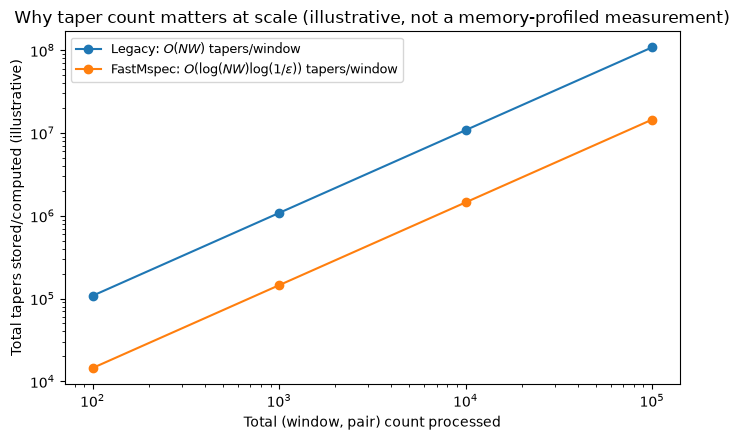

In [3]:
# Illustrative reproduction of the O(NW) vs O(log(NW) log(1/eps)) taper-count
# comparison behind that ~300GB vs ~20GB memory figure (Sayan's report Fig. 1).
n_windows = np.array([100, 1000, 10000, 100000])  # illustrative: windows x pairs
NW = 2 * 10800 * 0.05  # 3-hour window @ 1 Hz, W ~ 0.05 Hz (Love-wave bandwidth, per the report)
eps = 1e-9
legacy_tapers_per_window = NW
fast_tapers_per_window = np.log(NW) * np.log(1 / eps)

print(f"Per-window taper count: legacy (2NW) = {legacy_tapers_per_window:.0f}, "
      f"fast (log(NW)log(1/eps)) = {fast_tapers_per_window:.1f}")
print(f"Ratio: {legacy_tapers_per_window / fast_tapers_per_window:.1f}x fewer tapers with FastMspec\n")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(n_windows, n_windows * legacy_tapers_per_window, 'o-', label='Legacy: $O(NW)$ tapers/window')
ax.loglog(n_windows, n_windows * fast_tapers_per_window, 'o-', label=r'FastMspec: $O(\log(NW)\log(1/\epsilon))$ tapers/window')
ax.set_xlabel('Total (window, pair) count processed')
ax.set_ylabel('Total tapers stored/computed (illustrative)')
ax.set_title('Why taper count matters at scale (illustrative, not a memory-profiled measurement)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


This is illustrative scaling, not a re-measurement of Sayan's actual
~300GB/~20GB figures (those come from his own MATLAB memory profiling,
cited above, not reproduced here) — but it shows the same qualitative point
Notebook 1's Figs 7-8 made computationally: the gap between legacy and fast
grows, not shrinks, as the problem gets bigger. This is why the "Fast" in
FastMspec isn't a minor optimization for this application — the O(NW)
legacy approach reportedly does not fit in the memory available for the full
job, while the O(log(NW)log(1/ε)) approach does.


## 4. Bridge to Part 3: from auto-spectra to cross-spectra

Everything in Notebook 1 — including the paper's own Theorems and Figs 1-8 —
is about the **auto-spectrum** $S(f)$ of a single signal. Sayan's problem
needs the **cross-spectrum** $S_{xy}(f)$ between two stations' recordings,
which the Karnik paper itself does not cover; extending `FastMultitaper`
from auto- to cross-spectra required genuinely new math, not just calling
the existing paper's method twice.

That extension is `mspec_fast.m`'s `avgspec_xy_sayan` subfunction — a
MATLAB function whose name (`_sayan`) directly credits this as Sayan's own
contribution on top of the Karnik paper. It's already translated and
verified in this repo, at
[`python/ccf_pipeline/fast_cross_spectrum.py`](../python/ccf_pipeline/fast_cross_spectrum.py)'s
`fast_spectrum_batch(fmtse, x, y)`: the same `FastMultitaper` object from
Notebook 1 (`fmtse.S`, `fmtse.index_plus`, `fmtse.K`, `fmtse.vec_half_sinc`)
now cross-multiplies two signals' tapered spectra (`mmatx * conj(mmaty)`)
instead of squaring one, and is batched over many traces (station-pair
windows) at once — see the docstring there for the full correspondence to
the auto-spectrum case.

In [4]:
from thomson_multitaper import FastMultitaper
from ccf_pipeline.fast_cross_spectrum import fast_spectrum_batch

# Sanity check: fast_spectrum_batch(fmtse, x, x) (a cross-spectrum of a signal
# with itself) should reduce to FastMultitaper.spectral_estimate(x) (the
# auto-spectrum), up to the one-sided-vs-two-sided and (N,)-vs-(N,1) shape
# conventions the two functions use.
n = 2048
w = 0.01
rng = np.random.default_rng(0)
x = rng.standard_normal(n) + 1j * rng.standard_normal(n)

fmtse = FastMultitaper(n, w, 1 - 1e-6, 1e-9)
auto = fmtse.spectral_estimate(x)
cross_self = fast_spectrum_batch(fmtse, x[:, None], x[:, None])[:, 0]

onesided_len = n // 2 + 1
rel_err = np.max(np.abs(auto[:onesided_len].real - cross_self.real) / np.abs(auto[:onesided_len].real))
print(f"auto-spectrum (Notebook 1's method) vs. cross-spectrum-with-itself "
      f"(Part 3's method), one-sided bins: relative error = {rel_err:.2e}")


auto-spectrum (Notebook 1's method) vs. cross-spectrum-with-itself (Part 3's method), one-sided bins: relative error = 6.19e-16


This confirms the two code paths agree where they should — `fast_spectrum_batch`
is a genuine generalization of the `FastMultitaper.spectral_estimate` used
throughout Notebook 1, not an unrelated implementation. **Notebook 3** picks
up from here: applying this cross-spectrum machinery, through the full
`ccf_pipeline` (`ccf_compute_crosscorr_mtc_fastmspec` and friends), to real
SA53/SA58 and MTAN/RUNG station-pair data.
